# **Automatic Alternate Abbreviation Annotation:** Adding and processing gene-alias pairs

I am using Claude to try to identify alias symbols of genes that are just variations of abbreviations of the official(primary) gene symbols and the official gene name. The goal is to be able to do this automatically instead of manually. 
These symbols represent the gene with a different symbol than the primary gene symbol. For example, the official long gene name of HGNC:5 is “alpha-1-B glycoprotein” with a primary gene symbol of A1BG. One of the aliases is A1B which is found in PMID: 2447112 to represent “Alpha 1-beta glycoprotein”. This is the same official name of the gene but the abbreviation is different, A1B vs A1BG. 

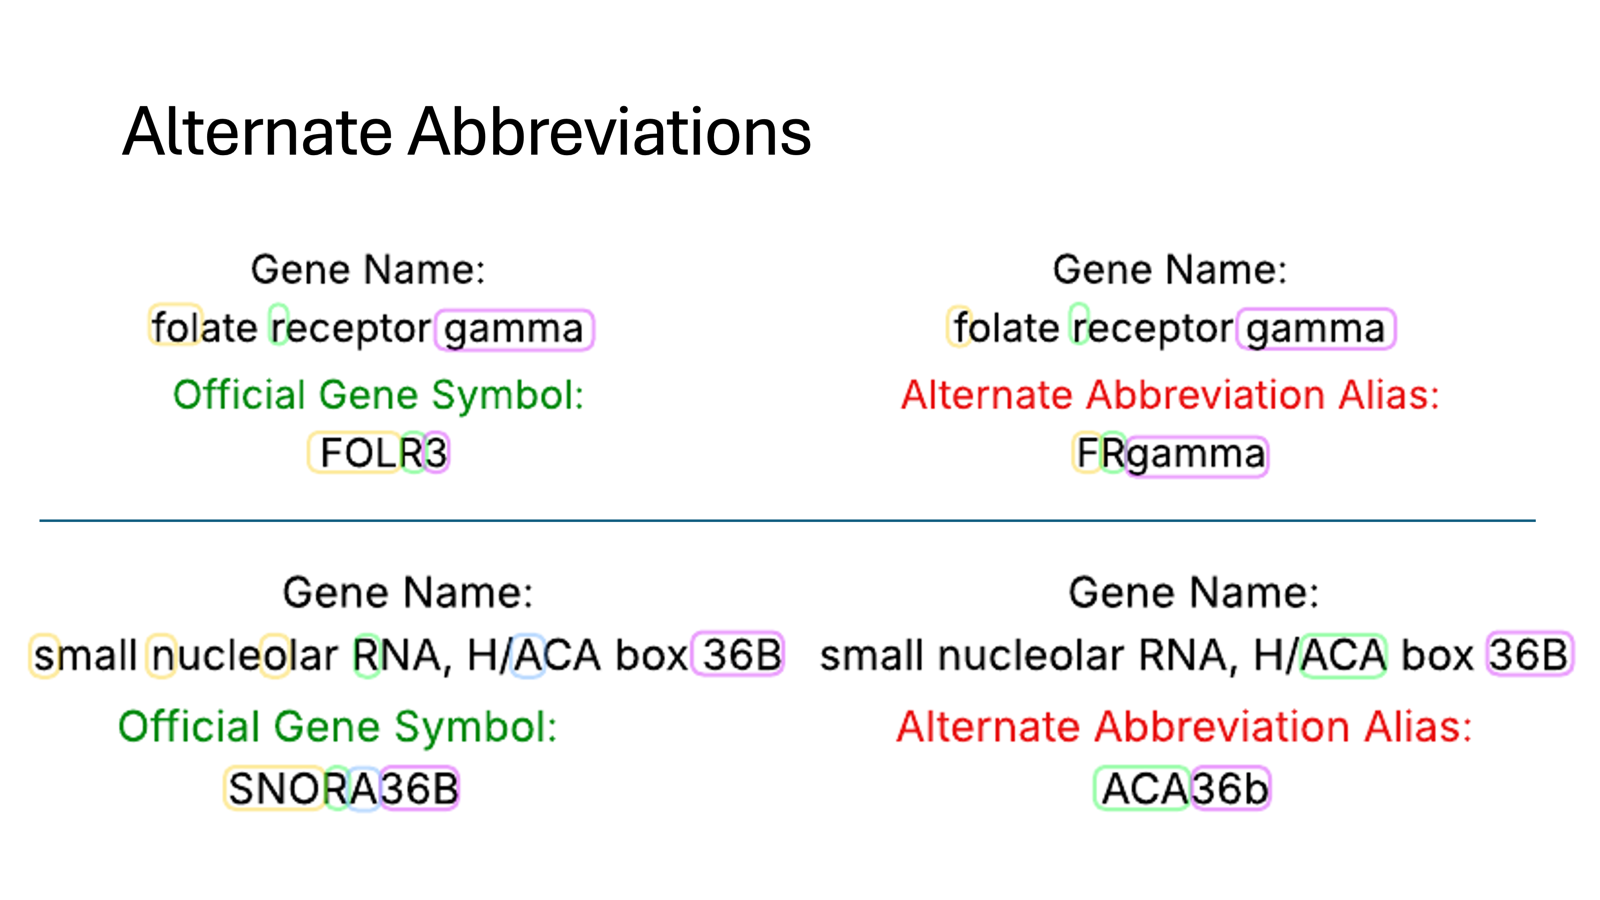

In [1]:
import requests
import time
import ast
from pathlib import Path
import polars as pl
from tqdm.notebook import tqdm

In [ ]:
def get_gene_name(hgnc_id):
    """Retrieve official gene name from HGNC for each sample in the set.

    :param hgnc_id: The HGNC ID to retrieve the official gene name for
    :return: The official HGNC gene name
    """
    url = f"https://rest.genenames.org/fetch/hgnc_id/{hgnc_id}"
    headers = {"Accept": "application/json"}  # Request JSON format
    time.sleep(0.5)
    response = requests.get(url, headers=headers)

    if response.status_code == 200:
        data = response.json()
        try:
            gene_name = data["response"]["docs"][0]["name"]
            return gene_name
        except IndexError:
            return f"No gene found for HGNC ID {hgnc_id}"
    else:
        return f"Error: {response.status_code}"

In [3]:
ALT_ABBREV_ROOT = Path.cwd().resolve()
ALT_ABBREV_OUTPUT_PATH = ALT_ABBREV_ROOT / "output"
GENE_HARMONY_OUTPUT_PATH = Path.cwd().resolve().parent.parent / "output"

## Define the number of new samples to add to the existing dataset

In [ ]:
NUMBER_OF_NEW_SAMPLES_TO_ADD = 2

## Load dataset with gene-alias pairs manually curated for Alternate Abbreviation alias symbols

In [ ]:
curated_df = pl.read_excel(
    ALT_ABBREV_OUTPUT_PATH / "alt_abbrev_annotation_manually_annotated_df.xlsx"
)

In [6]:
dedup_keys = ["primary_gene_symbol", "gene_symbol"]
curated_keys = curated_df.select(dedup_keys).unique()

## Load and clean dataset where to get new gene-alias pairs from

In [7]:
## This is the file with alias and primary gene symbol pairs and what categories the aliases were captured as
## Generated in the 5_symbol_capture_analysis.ipynb
## Clean it up with converting to booleans and renaming columns for clarity

ID_COLS = ["HGNC_ID", "ENSG_ID", "NCBI_ID"]

capture_df = (
    pl.read_csv(GENE_HARMONY_OUTPUT_PATH / "summary_df.csv")
    .rename(
        {
            "captured": "captured_status",
            "captured as:": "captured_category_list",
        }
    )
    .drop("")
    .with_columns(
        pl.when(pl.col("captured_status") == "T")
        .then(True)
        .when(pl.col("captured_status") == "F")
        .then(False)
        .otherwise(None)
        .alias("captured_status"),
        pl.col(ID_COLS).map_elements(
            lambda x: ", ".join(sorted(ast.literal_eval(x))) if x is not None else None,
            return_dtype=pl.String,
        ),
    )
)

## Remove samples already in dataset

In [8]:
eligible_df = capture_df.join(curated_keys, on=dedup_keys, how="anti")

## Select sample of new gene-alias pairs

In [9]:
## To add to the sample set for manual annotation

new_samples_df = eligible_df.group_by("captured_status").map_groups(
    lambda g: g.sample(
        n=min(len(g), NUMBER_OF_NEW_SAMPLES_TO_ADD // 2),
        seed=41,
    )
)

In [10]:
remaining = NUMBER_OF_NEW_SAMPLES_TO_ADD - new_samples_df.height

if remaining > 0:
    extra = eligible_df.join(
        new_samples_df.select(dedup_keys).unique(),
        on=dedup_keys,
        how="anti",
    ).sample(n=remaining, seed=41)

    new_samples_df = pl.concat([new_samples_df, extra])

## Add gene names to the new samples of gene-alias pairs

In [11]:
# Add gene_name column safely to new samples df

if "gene_name" not in new_samples_df.columns:
    new_samples_df = new_samples_df.with_columns(pl.lit(None).alias("gene_name"))

In [12]:
# Add gene names, by HGNC ID, to the annotation set for easier manual review

missing_ids = (
    new_samples_df.filter(pl.col("gene_name").is_null())
    .select("HGNC_ID")
    .unique()
    .to_series()
    .to_list()
)

gene_map = {hgnc_id: get_gene_name(hgnc_id) for hgnc_id in tqdm(missing_ids)}

new_samples_df = new_samples_df.with_columns(
    pl.col("gene_name").fill_null(pl.col("HGNC_ID").replace(gene_map))
)

  0%|          | 0/2 [00:00<?, ?it/s]

## Combine new samples with those already annotated

In [13]:
# Add blank column for manual annotation
new_samples_df = new_samples_df.with_columns(
    pl.lit(None).alias("alternate_abbreviation_status")
)
# Reorder columns to match curated set for concatenation
new_samples_df = new_samples_df.select(curated_df.columns)

In [14]:
df = pl.concat(
    [curated_df, new_samples_df],
    how="vertical",
)

## Export newly combined file for manually annotation in Excel

In [15]:
df.write_excel(ALT_ABBREV_OUTPUT_PATH / "alt_abbrev_annotation_to_annotate_df.xlsx")
f"The original set had {curated_df.height} samples, the new set has {df.height} samples after adding {new_samples_df.height} new samples"

'The original set had 505 samples, the new set has 507 samples after adding 2 new samples'

### After manually annotating the new rows in alt_abbrev_annotation_to_annotate_df.xlsx, it needs to be renamed and saved to alt_abbrev_annotation_**manually_annotated**_df.xlsx